[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


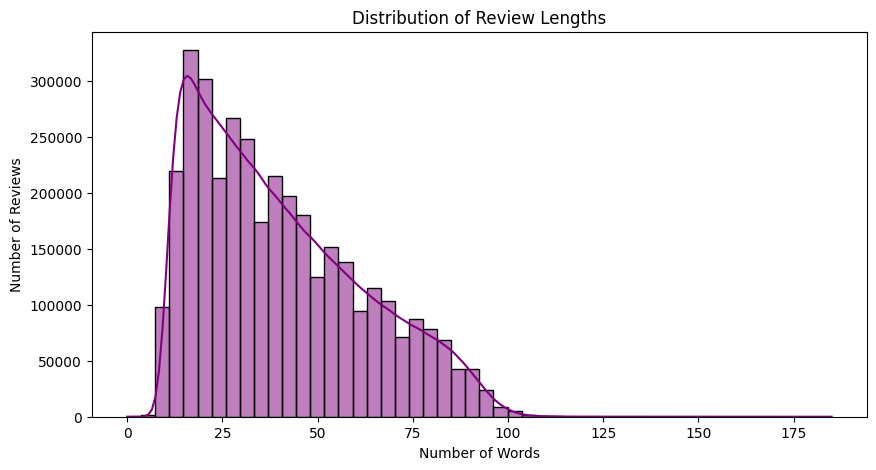

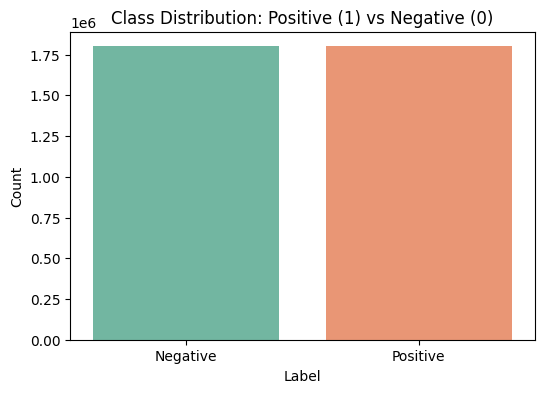

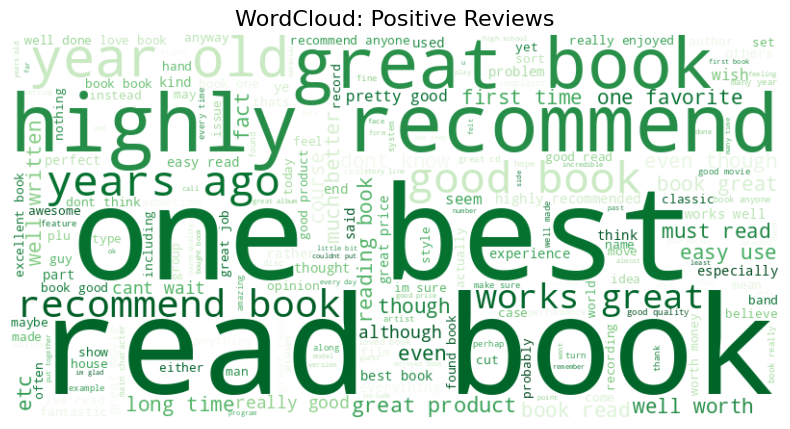

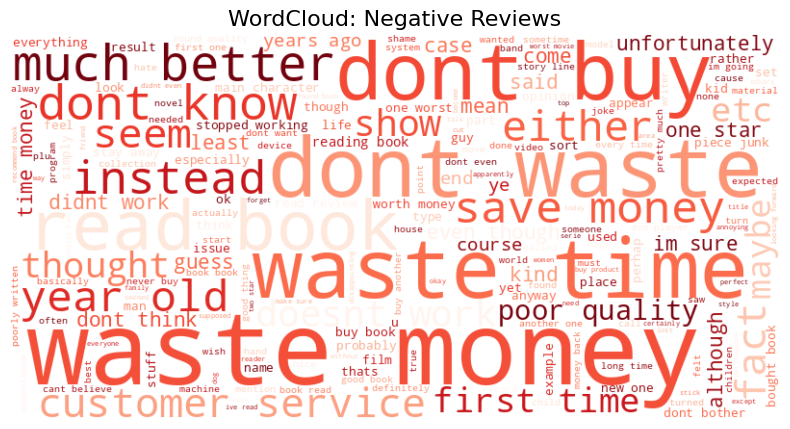

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


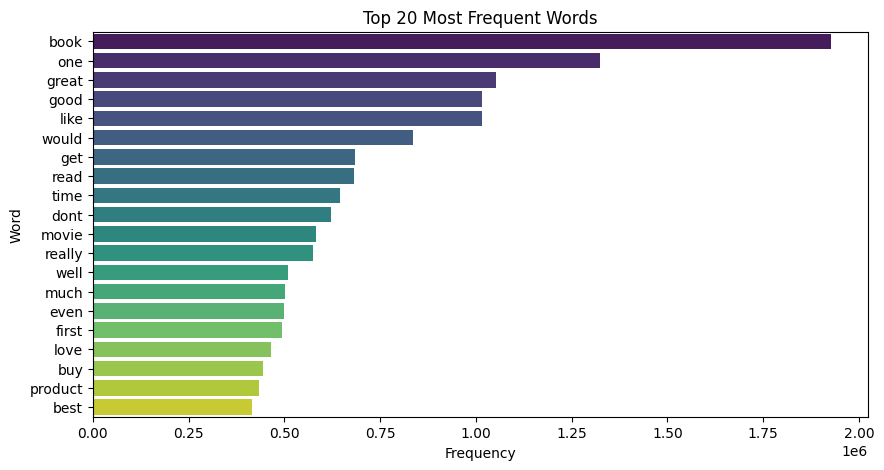


🔧 Training Logistic Regression...
📊 Logistic Regression Evaluation
🔹 Accuracy: 0.90657
🔹 F1 Score: 0.9068735920897874

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91    200000
           1       0.90      0.91      0.91    200000

    accuracy                           0.91    400000
   macro avg       0.91      0.91      0.91    400000
weighted avg       0.91      0.91      0.91    400000



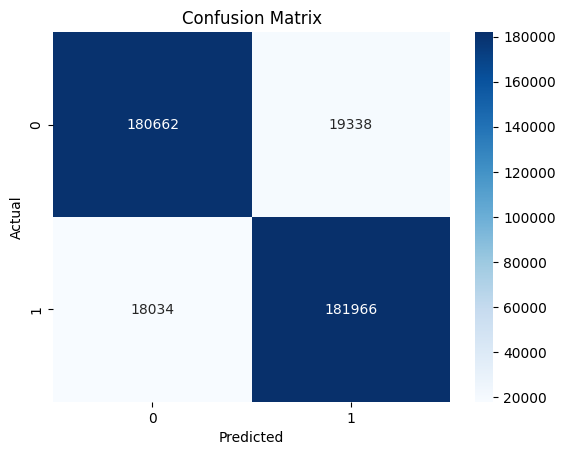

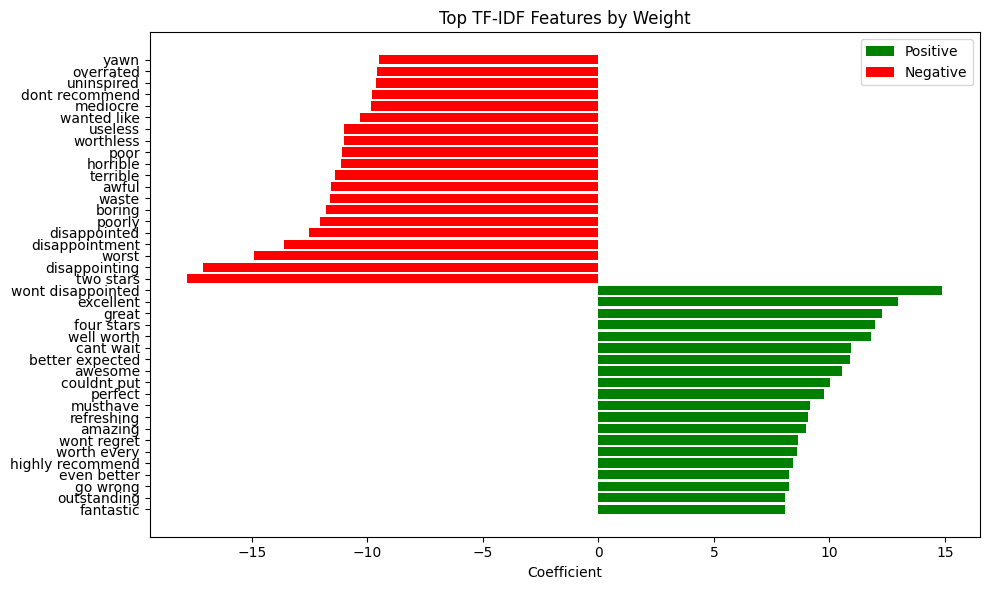


🔧 Training SVC...


In [ ]:
# ---------------------------------------
# 🚀 Amazon Reviews — Classical NLP Model
# ---------------------------------------

# ✅ INSTALL (if needed)
# Run this once to install required libraries:
# !pip install wordcloud nltk

# =========================
# 📚 Import Necessary Libraries
# =========================
import pandas as pd
import numpy as np
import re
import string
import nltk
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")

# =========================
# 📥 Load Dataset
# =========================
TRAIN_PATH = "/kaggle/input/nlp-amazon-review-dataset/train.csv"
TEST_PATH  = "/kaggle/input/nlp-amazon-review-dataset/test.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

# =========================
# 🧹 Text Cleaning Function
# =========================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def advanced_clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)               # Remove URLs
    text = re.sub(r"<.*?>", "", text)                 # Remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text)              # Remove punctuation and numbers
    tokens = word_tokenize(text)                      # Tokenize
    tokens = [t for t in tokens if t not in stop_words]  # Remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]   # Lemmatization
    return " ".join(tokens)                           # Re-join for vectorization

from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

def fast_clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = re.findall(r'\b\w+\b', text)  # Faster tokenizer
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

# Apply cleaning to train & test sets
df_train["cleaned"] = df_train["text"].apply(fast_clean_text)
df_test["cleaned"] = df_test["text"].apply(fast_clean_text)

# =========================
# 📊 Exploratory Data Analysis
# =========================

# 1️⃣ Review Length Distribution
df_train["review_length"] = df_train["cleaned"].apply(lambda x: len(nltk.word_tokenize(x)))
plt.figure(figsize=(10, 5))
sns.histplot(df_train["review_length"], bins=50, kde=True, color='purple')
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

# 2️⃣ Class Distribution Bar Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x="label", palette="Set2")
plt.title("Class Distribution: Positive (1) vs Negative (0)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.show()

# 3️⃣ WordClouds for Positive & Negative Reviews
def generate_wordcloud(text_series, title, color):
    text = " ".join(text_series)
    wc = WordCloud(width=800, height=400, background_color="white", colormap=color).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

generate_wordcloud(df_train[df_train["label"] == 1]["cleaned"], "WordCloud: Positive Reviews", "Greens")
generate_wordcloud(df_train[df_train["label"] == 0]["cleaned"], "WordCloud: Negative Reviews", "Reds")

# 4️⃣ Top 20 Frequent Words
all_tokens = " ".join(df_train["cleaned"]).split()
top_tokens = Counter(all_tokens).most_common(20)
words, freqs = zip(*top_tokens)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(freqs), y=list(words), palette="viridis")
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

# =========================
# 🧠 TF-IDF Vectorization
# =========================
def vectorize_text(train_texts, test_texts, max_features=10000):
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2))
    X_train = tfidf.fit_transform(train_texts)
    X_test = tfidf.transform(test_texts)
    return X_train, X_test, tfidf

# =========================
# 🤖 Model Trainer
# =========================
def train_model(X_train, y_train, model_type="logistic"):
    if model_type == "logistic":
        model = LogisticRegression(max_iter=1000)
    elif model_type == "svc":
        model = SVC(probability=True)
    else:
        raise ValueError("Choose either 'logistic' or 'svc'")
    model.fit(X_train, y_train)
    return model

# =========================
# 📊 Evaluation Function
# =========================
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("🔹 Accuracy:", accuracy_score(y_test, y_pred))
    print("🔹 F1 Score:", f1_score(y_test, y_pred))
    print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =========================
# 📈 Visualize Important Features
# =========================
def plot_feature_importance(tfidf, model, top_n=20):
    if not hasattr(model, "coef_"):
        print("⚠️ Model does not support coef_")
        return
    feature_names = np.array(tfidf.get_feature_names_out())
    coef = model.coef_.flatten()
    top_pos = np.argsort(coef)[-top_n:]
    top_neg = np.argsort(coef)[:top_n]
    plt.figure(figsize=(10, 6))
    plt.barh(feature_names[top_pos], coef[top_pos], color='green', label="Positive")
    plt.barh(feature_names[top_neg], coef[top_neg], color='red', label="Negative")
    plt.title("Top TF-IDF Features by Weight")
    plt.xlabel("Coefficient")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================
# 🗺️ 2D Vector Space Projection
# =========================
def plot_tfidf_projection(X, y, method="pca", sample_size=1000):
    idx = np.random.choice(X.shape[0], sample_size, replace=False)
    X_sample = X[idx].toarray()
    y_sample = np.array(y)[idx]

    if method == "pca":
        reducer = PCA(n_components=2)
    elif method == "tsne":
        reducer = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42)
    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    X_2d = reducer.fit_transform(X_sample)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y_sample, palette=["red", "green"], alpha=0.6)
    plt.title(f"2D Projection of TF-IDF Vectors ({method.upper()})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(title="Label", labels=["Negative", "Positive"])
    plt.show()

# =========================
# 🚀 Full Pipeline Execution
# =========================

# 🧾 Prepare input & labels
X_train_texts = df_train["cleaned"]
y_train = df_train["label"]
X_test_texts = df_test["cleaned"]
y_test = df_test["label"]

# ✨ TF-IDF Vectorization
X_train_vec, X_test_vec, tfidf = vectorize_text(X_train_texts, X_test_texts)

# 1️⃣ Logistic Regression
print("\n🔧 Training Logistic Regression...")
lr_model = train_model(X_train_vec, y_train, model_type="logistic")
print("📊 Logistic Regression Evaluation")
evaluate_model(lr_model, X_test_vec, y_test)
plot_feature_importance(tfidf, lr_model)

# 2️⃣ Support Vector Classifier (SVC)
print("\n🔧 Training SVC...")
svc_model = train_model(X_train_vec, y_train, model_type="svc")
print("📊 SVC Evaluation")
evaluate_model(svc_model, X_test_vec, y_test)

# 🔍 2D TF-IDF Projections
plot_tfidf_projection(X_train_vec, y_train, method="pca")
plot_tfidf_projection(X_train_vec, y_train, method="tsne")

In [ ]:
# 🔍 2D TF-IDF Projections
plot_tfidf_projection(X_train_vec, y_train, method="pca")
plot_tfidf_projection(X_train_vec, y_train, method="tsne")